# Financial Analysis of the Indian IT Services Sector Using Python


---

| | |
|---|---|
| **Coverage Universe** | TCS · Infosys · Wipro · HCL Technologies · Tech Mahindra |
| **Analysis Period** | 1 April 2020 – 31 March 2025 (5 fiscal years) |
| **Benchmarks** | NIFTY 50 (`^NSEI`) · NIFTY IT (`^CNXIT`) |
| **Data Source** | Yahoo Finance (`yfinance`) |
| **Python Libraries Used** | `pandas` · `numpy` · `matplotlib` · `seaborn` · `yfinance` |
| **Methodology** | Price performance, risk-adjusted returns, rolling volatility & beta, correlation, relative valuation, DuPont ROE decomposition |

---

By Yash Vikas Shinde

---

Disclaimer : This report is made for educational purpose only and is not a buy or sell recommendation.


## Executive Summary

India's IT services companies — TCS, Infosys, Wipro, HCL Technologies, and Tech Mahindra compete globally in the same market: enterprise consulting, application development, cloud migration, and outsourced technology services for large multinational clients. This report applies a standard equity research toolkit  total return, risk-adjusted performance, rolling volatility and beta, correlation, and relative valuation to these five companies across a five-year window spanning the COVID-era digital transformation boom, the 2022–2023 global tech-spending slowdown, and the subsequent recovery.

**How to read this report:** Sections 1–10 build the evidence base (price performance, risk, valuation). Section 11 (Executive Dashboard) consolidates the headline metrics. Section 12 (Investment Insights) turns those metrics into analyst-style recommendations.

**Key themes:**
- Which company delivers the best **risk-adjusted** returns, not just the highest headline return
- How **valuation** (P/E) compares against **profitability** (ROE) across the peer set
- Which names are **defensive** versus **more sensitive to global tech spending cycles**
- What the numbers imply for a **long-term investor**

All figures are generated live from Yahoo Finance data at run-time — nothing is hard-coded.

---


## 1. IT Services Sector Overview & Investment Rationale

### Why Indian IT Services Equities?

These five companies operate the same global business model, they sell consulting, systems integration, application development, and managed IT services to large enterprise clients mostly billed in USD and EUR using a largely India-based delivery workforce. Understanding what drives their stock performance is directly transferable to understanding it's competitive environment.

**Currency Exposure.** Revenue is earned mostly in USD/EUR/GBP while costs (salaries) are mostly in INR so a weaker rupee tends to help margins, and a stronger rupee tends to hurt them, independent of how the underlying business is performing.

**Global Tech Spending Cycles.** Unlike FMCG, demand here follows corporate IT budgets, not consumer spending. When global enterprises (especially in the US and Europe  the largest client markets) tighten technology and discretionary spending, deal flow and revenue growth slow across the whole sector simultaneously  this is exactly what happened industry-wide in 2022–2023.

**Utilization & Attrition.** Profitability is driven by how efficiently companies deploy their workforce (utilization rate) and how much they spend on hiring/training to replace departing employees (attrition). These operating metrics matter more here than in most other sectors.

**Deal Wins & Digital Transformation.** Large multi-year contract wins (measured in Total Contract Value, or TCV) and demand for cloud, AI, and digital transformation services are the primary growth drivers.

### Coverage Universe

| Company | Category | Investment Thesis Angle |
|------|----------|--------------------------|
| TCS | Largest IT services company | Scale leader; highest margins in the peer set; premium valuation|
| Infosys | Tier-1 IT services & consulting | Strong digital/cloud revenue mix; consistent margin discipline |
| Wipro | Tier-1 IT services | Historically the laggard on growth and margins among the large-caps; ongoing turnaround narrative |
| HCL Technologies | IT services + software products | Diversified into proprietary software (Mode 2/3 businesses), not just services |
| Tech Mahindra | Telecom-focused IT services | More concentrated client base (telecom vertical); historically more volatile margins |

---


## 2. Analytical Workflow

The chart below summarizes the process used to build this report, from raw data through to investment conclusions.


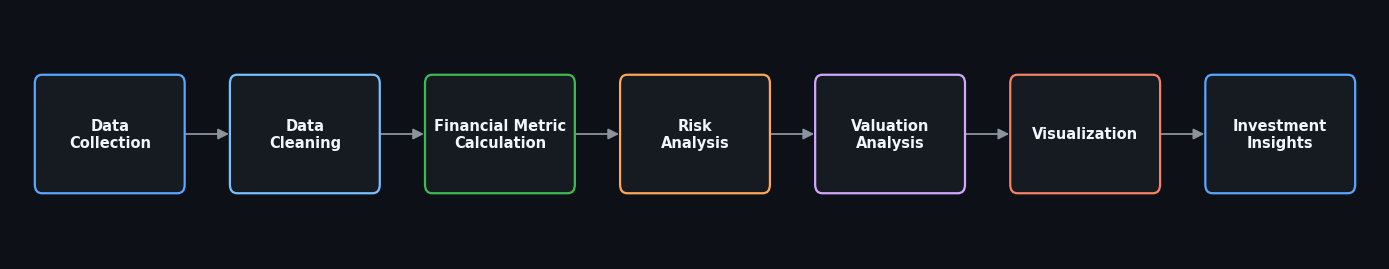

In [1]:
# Draw a simple flow diagram showing the steps in this analysis
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = ["Data\nCollection", "Data\nCleaning", "Financial Metric\nCalculation",
         "Risk\nAnalysis", "Valuation\nAnalysis", "Visualization", "Investment\nInsights"]
colors = ['#58a6ff', '#79c0ff', '#3fb950', '#ffa657', '#d2a8ff', '#f78166', '#58a6ff']

fig, ax = plt.subplots(figsize=(14, 2.8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

n = len(steps)
box_w, box_h, gap = 1.65, 1.05, 0.55
total_w = n * box_w + (n - 1) * gap
x0 = -total_w / 2

for i, (step, c) in enumerate(zip(steps, colors)):
    x = x0 + i * (box_w + gap)
    box = FancyBboxPatch((x, -box_h/2), box_w, box_h,
                          boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.6, edgecolor=c, facecolor='#161b22', zorder=3)
    ax.add_patch(box)
    ax.text(x + box_w/2, 0, step, ha='center', va='center',
            fontsize=10.5, color='#f0f6fc', fontweight='bold', zorder=4)
    if i < n - 1:
        arrow = FancyArrowPatch((x + box_w, 0), (x + box_w + gap, 0),
                                 arrowstyle='-|>', mutation_scale=16,
                                 color='#8b949e', linewidth=1.3, zorder=2)
        ax.add_patch(arrow)

ax.set_xlim(x0 - 0.3, x0 + total_w + 0.3)
ax.set_ylim(-1.15, 1.15)
ax.axis('off')
plt.tight_layout()
plt.show()

---


## 3. Environment Setup & Data Infrastructure


In [2]:
# Import the libraries we need and set a consistent dark chart style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

# ── Visualization Style: Institutional Dark Theme ─────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlecolor':   '#f0f6fc',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'axes.labelsize':    11,
    'axes.labelpad':     8,
    'axes.grid':         True,
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'xtick.labelsize':   9.5,
    'ytick.labelsize':   9.5,
    'text.color':        '#c9d1d9',
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'legend.fontsize':   10,
    'figure.titlesize':  16,
    'figure.titleweight':'bold',
    'lines.linewidth':   1.8,
    'savefig.facecolor': '#0d1117',
    'savefig.dpi':       150,
    'figure.autolayout': False,
})

# ── Color Palette ──────────────────────────────────────────────────────────────
IT_COLORS = {
    'TCS.NS':      '#58a6ff',
    'INFY.NS':     '#3fb950',
    'WIPRO.NS':    '#f78166',
    'HCLTECH.NS':  '#d2a8ff',
    'TECHM.NS':    '#ffa657',
}
BENCH_COLORS = {'NIFTY50': '#ffffff', 'NIFTYIT': '#79c0ff'}

## 4. Data Collection

Adjusted closing prices are sourced from Yahoo Finance for **1 April 2020 – 31 March 2025**, spanning five fiscal years. Adjusted prices account for dividends and corporate actions, so returns reflect the actual investor experience.

Benchmarks — **NIFTY 50** (`^NSEI`) and **NIFTY IT** (`^CNXIT`) — are downloaded alongside the five companies for relative performance and beta analysis.


In [3]:
# Define which companies and benchmarks to analyze, and over what date range
IT_STOCKS = ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS']
IT_NAMES = {
    'TCS.NS':      'TCS',
    'INFY.NS':     'Infosys',
    'WIPRO.NS':    'Wipro',
    'HCLTECH.NS':  'HCL Tech',
    'TECHM.NS':    'Tech Mahindra',
}

START_DATE = '2020-04-01'
END_DATE   = '2025-03-31'
RISK_FREE  = 0.065  # Approximate average 91-day T-Bill yield over the study period

# ── Download Company & Benchmark Data ──────────────────────────────────────────
raw       = yf.download(IT_STOCKS, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
adj_close = raw['Adj Close']

bench_raw   = yf.download(['^NSEI', '^CNXIT'], start=START_DATE, end=END_DATE,
                           auto_adjust=False, progress=False)
bench_close = bench_raw['Adj Close']
bench_close.columns = ['NIFTY50', 'NIFTYIT']

## 5. Data Cleaning

Before computing any metric, the raw data is cleaned and aligned:

1. **Missing values** — gaps and non-trading days are checked and removed.
2. **Calendar alignment** — company and benchmark prices are matched to a common set of trading dates, since minor holiday mismatches would otherwise distort returns.
3. **Corporate actions** — using *adjusted* close means splits, bonuses, and dividends are already reflected, so no separate adjustment is needed.


In [4]:
# Check for missing data, then line up all price series on the same trading dates
missing_summary = pd.DataFrame({'Missing (Company Prices)': adj_close.isna().sum()}).rename(index=lambda t: IT_NAMES.get(t, t))
missing_summary.loc['NIFTY 50'] = bench_close['NIFTY50'].isna().sum()
missing_summary.loc['NIFTY IT'] = bench_close['NIFTYIT'].isna().sum()

# ── Clean & Align Trading Calendars ────────────────────────────────────────────
adj_close   = adj_close.dropna()
bench_close = bench_close.dropna()
common_idx  = adj_close.index.intersection(bench_close.index)
adj_close   = adj_close.loc[common_idx]
bench_close = bench_close.loc[common_idx]

data_quality = pd.DataFrame({
    'Metric': ['Trading Days (Post-Clean)', 'Start Date', 'End Date', 'Companies Covered', 'Benchmarks Covered'],
    'Value': [len(adj_close), str(adj_close.index[0].date()), str(adj_close.index[-1].date()),
              adj_close.shape[1], bench_close.shape[1]]
})
data_quality.style.hide(axis='index').set_caption('Data Quality Snapshot (Post-Cleaning)')

Metric,Value
Trading Days (Post-Clean),1235
Start Date,2020-04-01
End Date,2025-03-28
Companies Covered,5
Benchmarks Covered,2


---


## 6. Stock Price Performance

Cumulative returns, indexed to 100 at the start of the period, are the primary lens for comparing total return delivery across companies and benchmarks.


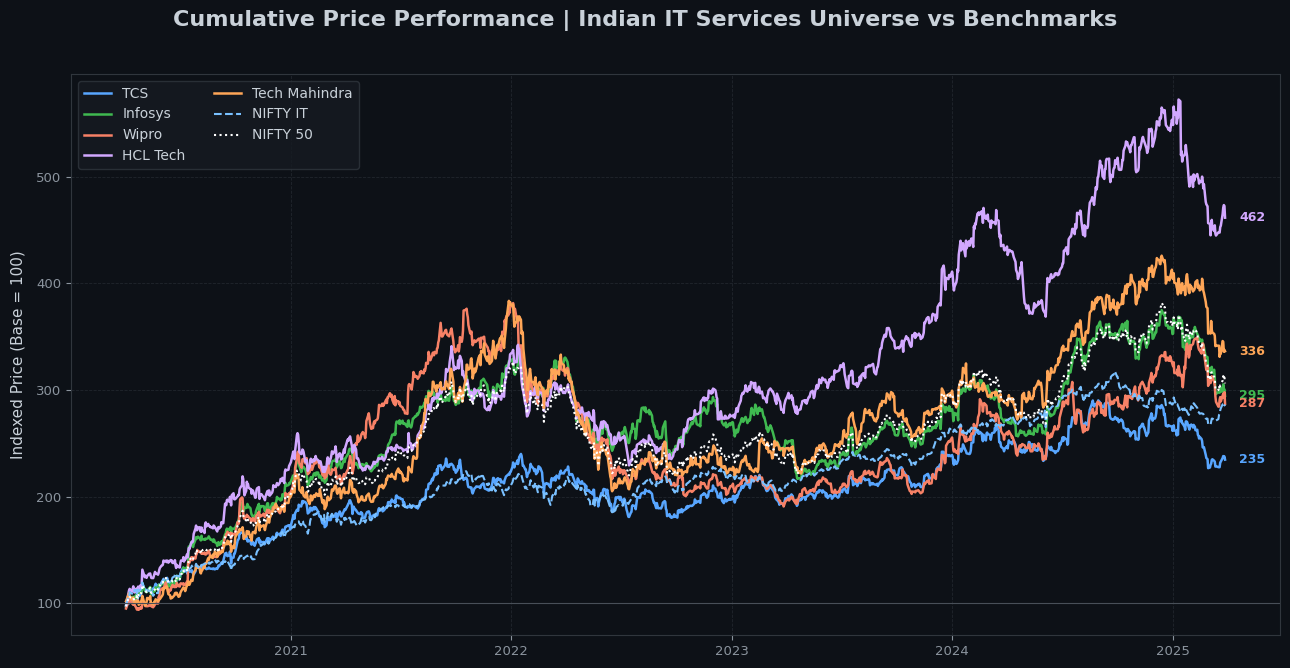

,Terminal Value (Base=100),Total Return (%)
Ticker,,
HCL Tech,461.700000,361.700000
Tech Mahindra,336.400000,236.400000
Infosys,294.500000,194.500000
Wipro,287.000000,187.000000
TCS,234.700000,134.700000


In [5]:
# Turn prices into daily returns, then compound them into a cumulative return
daily_returns = adj_close.pct_change().dropna()
bench_returns = bench_close.pct_change().dropna()

cum_ret   = (1 + daily_returns).cumprod() * 100
cum_bench = (1 + bench_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.suptitle('Cumulative Price Performance | Indian IT Services Universe vs Benchmarks', y=1.02)

for tkr in IT_STOCKS:
    ax.plot(cum_ret.index, cum_ret[tkr], color=IT_COLORS[tkr], label=IT_NAMES[tkr])
ax.plot(cum_bench.index, cum_bench['NIFTYIT'], color=BENCH_COLORS['NIFTYIT'], ls='--', lw=1.5, label='NIFTY IT')
ax.plot(cum_bench.index, cum_bench['NIFTY50'], color=BENCH_COLORS['NIFTY50'], ls=':', lw=1.5, label='NIFTY 50')

ax.axhline(100, color='#484f58', lw=0.8)
ax.set_ylabel('Indexed Price (Base = 100)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
ax.legend(loc='upper left', ncol=2, frameon=True)

for tkr in IT_STOCKS:
    val = cum_ret[tkr].iloc[-1]
    ax.annotate(f'{val:.0f}', xy=(cum_ret.index[-1], val), xytext=(10, 0),
                textcoords='offset points', color=IT_COLORS[tkr], fontsize=9, va='center', fontweight='bold')

plt.tight_layout()
plt.show()

terminal = pd.DataFrame({
    'Terminal Value (Base=100)': cum_ret.iloc[-1].round(1),
    'Total Return (%)': (cum_ret.iloc[-1] - 100).round(1)
}).rename(index=IT_NAMES).sort_values('Total Return (%)', ascending=False)

terminal.style.background_gradient(cmap='Greens', subset=['Total Return (%)']).set_caption('Total Return Summary (FY2020–FY2025)')

**Interpretation:** Total return alone doesn't tell us whether it was earned efficiently. A company compounding steadily through the 2022–2023 tech-spending slowdown is a very different holding from one that only did well during the COVID digital-transformation boom. Risk-adjusted return, covered next, is the more useful comparison.

---


## 7. Risk vs Return Analysis

### 7.1 Annual Returns, Volatility & Sharpe Ratio

- **Annual Return** — mean daily return, annualized over 252 trading days
- **Annualized Volatility** — standard deviation of daily returns, annualized
- **Sharpe Ratio** — excess return per unit of risk, using a **6.5% risk-free rate**
- **Maximum Drawdown** — worst peak-to-trough decline
- **Calmar Ratio** — annual return ÷ max drawdown, a downside-focused alternative to Sharpe


In [6]:
# Calculate annualized return, volatility, Sharpe ratio, drawdown, and Calmar ratio
ann_return = daily_returns.mean() * 252
ann_vol    = daily_returns.std() * np.sqrt(252)
sharpe     = (ann_return - RISK_FREE) / ann_vol

def max_drawdown(ret_series):
    cum = (1 + ret_series).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

max_dd = daily_returns.apply(max_drawdown)
calmar = ann_return / abs(max_dd)

rr = pd.DataFrame({
    'Annual Return':  ann_return, 'Annualized Vol': ann_vol, 'Sharpe Ratio': sharpe.round(2),
    'Max Drawdown': max_dd, 'Calmar Ratio': calmar.round(2),
}).rename(index=IT_NAMES).sort_values('Sharpe Ratio', ascending=False)

(rr.style
   .format({'Annual Return': '{:.1%}', 'Annualized Vol': '{:.1%}', 'Max Drawdown': '{:.1%}'})
   .background_gradient(cmap='RdYlGn', subset=['Sharpe Ratio'])
   .set_caption('Risk-Return Summary Table (FY2020–FY2025)'))

,Annual Return,Annualized Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio
Ticker,,,,,
HCL Tech,34.8%,26.5%,1.070000,-33.0%,1.050000
Tech Mahindra,28.9%,28.8%,0.780000,-46.6%,0.620000
Infosys,25.4%,25.8%,0.730000,-35.6%,0.710000
Wipro,25.5%,28.5%,0.670000,-50.0%,0.510000
TCS,20.0%,22.9%,0.590000,-25.0%,0.800000


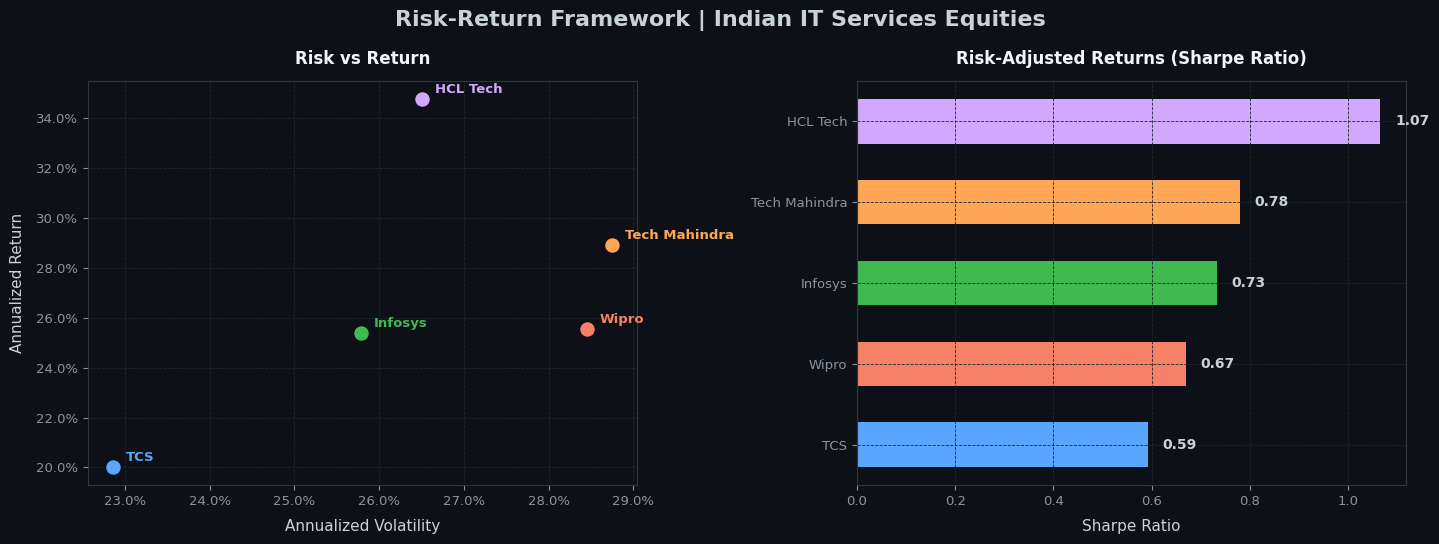

In [7]:
# Plot risk vs return, and rank the companies by Sharpe ratio
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))
fig.suptitle('Risk-Return Framework | Indian IT Services Equities')

ax = axes[0]
for tkr in IT_STOCKS:
    ax.scatter(ann_vol[tkr], ann_return[tkr], color=IT_COLORS[tkr], s=130, zorder=3, edgecolor='#0d1117', linewidth=1)
    ax.annotate(IT_NAMES[tkr], (ann_vol[tkr], ann_return[tkr]), textcoords='offset points',
                xytext=(9, 4), fontsize=9.5, color=IT_COLORS[tkr], fontweight='bold')
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Risk vs Return', fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax2 = axes[1]
sharpe_named = sharpe.rename(index=IT_NAMES).sort_values(ascending=True)
bar_colors   = [IT_COLORS[t] for t in sharpe.sort_values(ascending=True).index]
bars = ax2.barh(sharpe_named.index, sharpe_named.values, color=bar_colors, height=0.55)
ax2.axvline(0, color='#484f58', lw=0.8)
for bar, val in zip(bars, sharpe_named.values):
    ax2.text(val + 0.03, bar.get_y() + bar.get_height() / 2, f'{val:.2f}', va='center', fontsize=10, color='#c9d1d9', fontweight='bold')
ax2.set_xlabel('Sharpe Ratio')
ax2.set_title('Risk-Adjusted Returns (Sharpe Ratio)', fontsize=12)

plt.tight_layout()
plt.show()

**Interpretation:** Sharpe ratio, not raw return, is the number a research desk leads with — it shows how much return an investor gets per unit of risk. A name in the top-left of the scatter (low volatility, high return) is the most capital-efficient holding; one in the bottom-right is taking on more risk without proportionate extra return.

---


### 7.2 Rolling Volatility & Rolling Sharpe

Static full-period metrics mask time-varying risk. Rolling 63-day (roughly one fiscal quarter) volatility and Sharpe reveal how each company's risk profile shifted through the COVID digital-transformation boom, the 2022–2023 global tech-spending slowdown, and the recovery that followed.


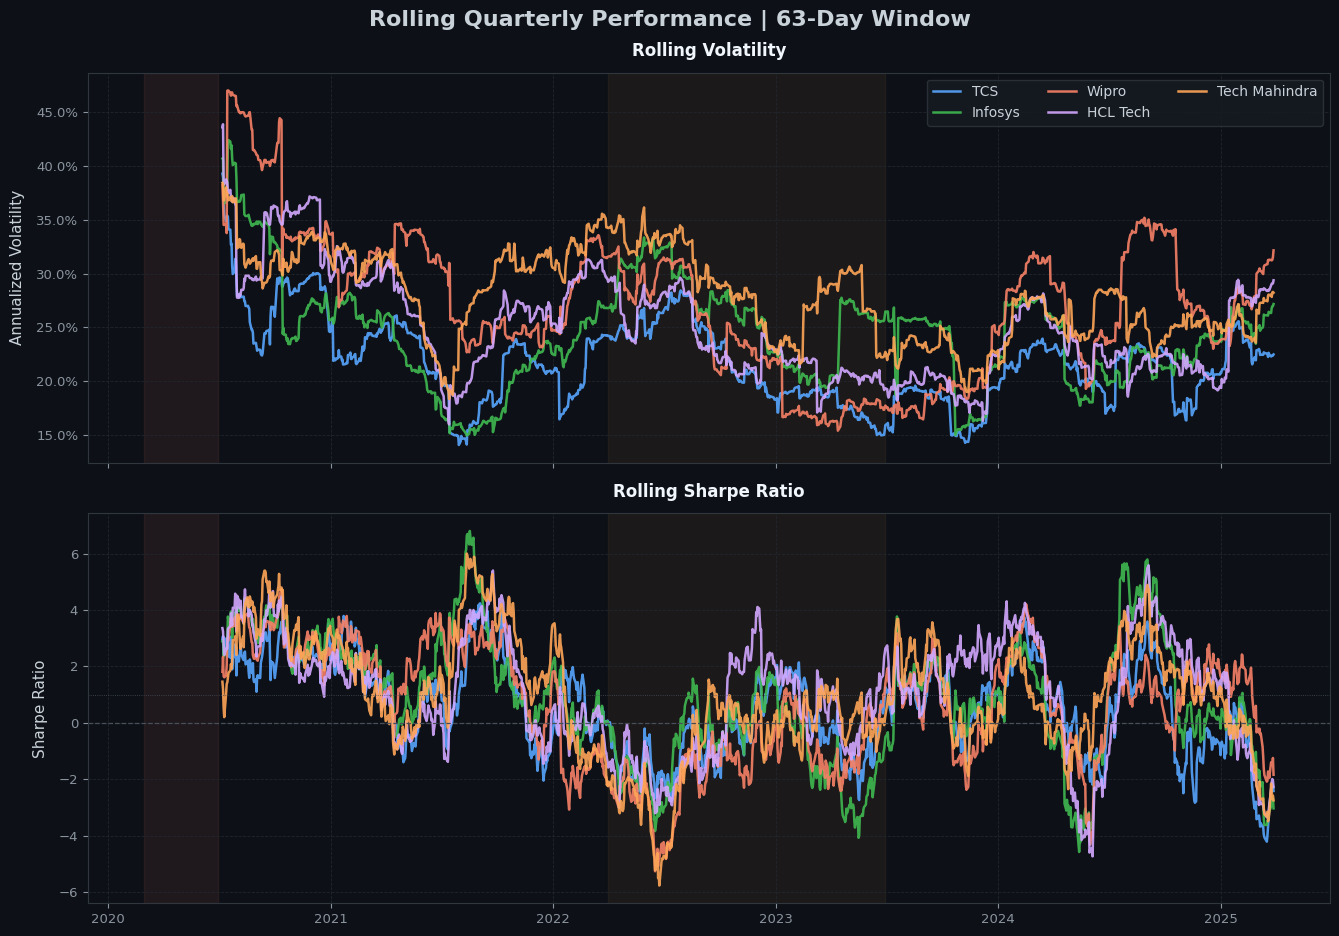

In [8]:
# Redo volatility and Sharpe ratio using a rolling 63-day window instead of the full period
roll_vol    = daily_returns.rolling(63).std() * np.sqrt(252)
roll_ret    = daily_returns.rolling(63).mean() * 252
roll_sharpe = (roll_ret - RISK_FREE) / roll_vol

fig, axes = plt.subplots(2, 1, figsize=(13.5, 9.5), sharex=True)
fig.suptitle('Rolling Quarterly Performance | 63-Day Window')

ax1 = axes[0]
for tkr in IT_STOCKS:
    ax1.plot(roll_vol.index, roll_vol[tkr], color=IT_COLORS[tkr], label=IT_NAMES[tkr], alpha=0.9)
ax1.set_ylabel('Annualized Volatility')
ax1.set_title('Rolling Volatility', fontsize=12)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.legend(ncol=3, frameon=True)

ax2 = axes[1]
for tkr in IT_STOCKS:
    ax2.plot(roll_sharpe.index, roll_sharpe[tkr], color=IT_COLORS[tkr], alpha=0.9)
ax2.axhline(0, color='#484f58', lw=0.9, ls='--')
ax2.axhline(1, color='#484f58', lw=0.6, ls=':')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Rolling Sharpe Ratio', fontsize=12)

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'), color='#f78166', alpha=0.08, label='COVID Shock')
    ax.axvspan(pd.Timestamp('2022-04-01'), pd.Timestamp('2023-06-30'), color='#ffa657', alpha=0.06, label='Global Tech Slowdown')

plt.tight_layout()
plt.show()

**Interpretation:** The shaded windows mark the two biggest episodes in the period. A company whose rolling Sharpe holds up through the global tech slowdown shows resilient client demand and pricing power; one that dips sharply is more exposed to discretionary IT budget cuts at its clients.

---


## 8. Maximum Drawdown Analysis

Maximum drawdown — the worst peak-to-trough decline — is an intuitive downside-risk measure. Large drawdowns are what actually test an investor's conviction to hold a position, which is why this matters as much as volatility.


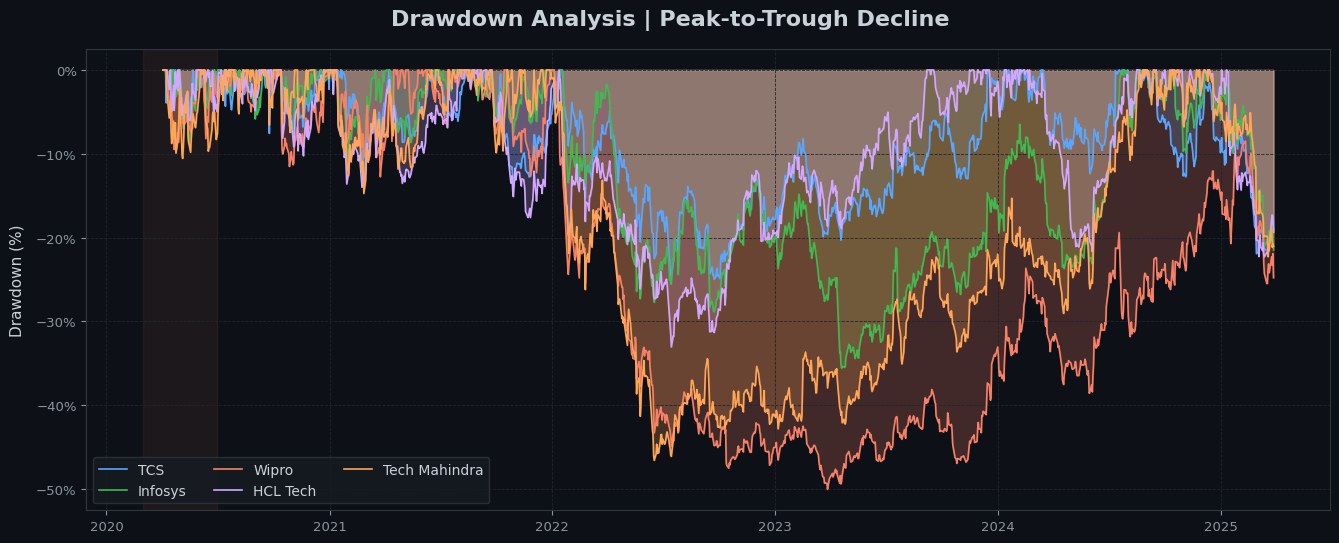

In [9]:
# Define a function that tracks how far a company has fallen from its highest-ever value
def drawdown_series(ret_series):
    cum = (1 + ret_series).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

fig, ax = plt.subplots(figsize=(13.5, 5.5))
fig.suptitle('Drawdown Analysis | Peak-to-Trough Decline')

for tkr in IT_STOCKS:
    dd = drawdown_series(daily_returns[tkr])
    ax.fill_between(dd.index, dd * 100, 0, color=IT_COLORS[tkr], alpha=0.22)
    ax.plot(dd.index, dd * 100, color=IT_COLORS[tkr], label=IT_NAMES[tkr], lw=1.2)

ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'), color='#f78166', alpha=0.07)
ax.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()

**Interpretation:** All five companies saw meaningful declines during COVID and again during the 2022–2023 slowdown, when clients paused discretionary technology spending. The size and speed of recovery is what separates a resilient, diversified franchise from one more exposed to a handful of large clients or a single vertical.

---


## 9. Beta Analysis

Rolling 252-day beta against NIFTY 50 measures systematic market sensitivity; alpha captures stock-specific performance.

**Beta interpretation:** Beta > 1 amplifies market moves; Beta < 1 is defensive; Beta ≈ 1 tracks the market.


In [10]:
# Calculate each company's beta and alpha versus the NIFTY 50
nifty50_ret = bench_returns['NIFTY50']
niftyit_ret = bench_returns['NIFTYIT']

beta_data, alpha_data = {}, {}
for tkr in IT_STOCKS:
    cov   = np.cov(daily_returns[tkr].values, nifty50_ret.values)[0, 1]
    var   = np.var(nifty50_ret.values)
    beta  = cov / var
    alpha = (daily_returns[tkr].mean() - beta * nifty50_ret.mean()) * 252
    beta_data[IT_NAMES[tkr]]  = round(beta, 3)
    alpha_data[IT_NAMES[tkr]] = alpha

beta_df = pd.DataFrame({'Beta (vs NIFTY 50)': beta_data, 'Annualized Alpha': alpha_data})
(beta_df.style
    .format({'Annualized Alpha': '{:.1%}'})
    .background_gradient(cmap='RdYlGn_r', subset=['Beta (vs NIFTY 50)'])
    .set_caption('Beta & Alpha Summary (Full Period vs NIFTY 50)'))

,Beta (vs NIFTY 50),Annualized Alpha
TCS,0.882000,-2.2%
Infosys,1.057000,-1.3%
Wipro,0.981000,0.8%
HCL Tech,0.963000,10.4%
Tech Mahindra,1.011000,3.4%


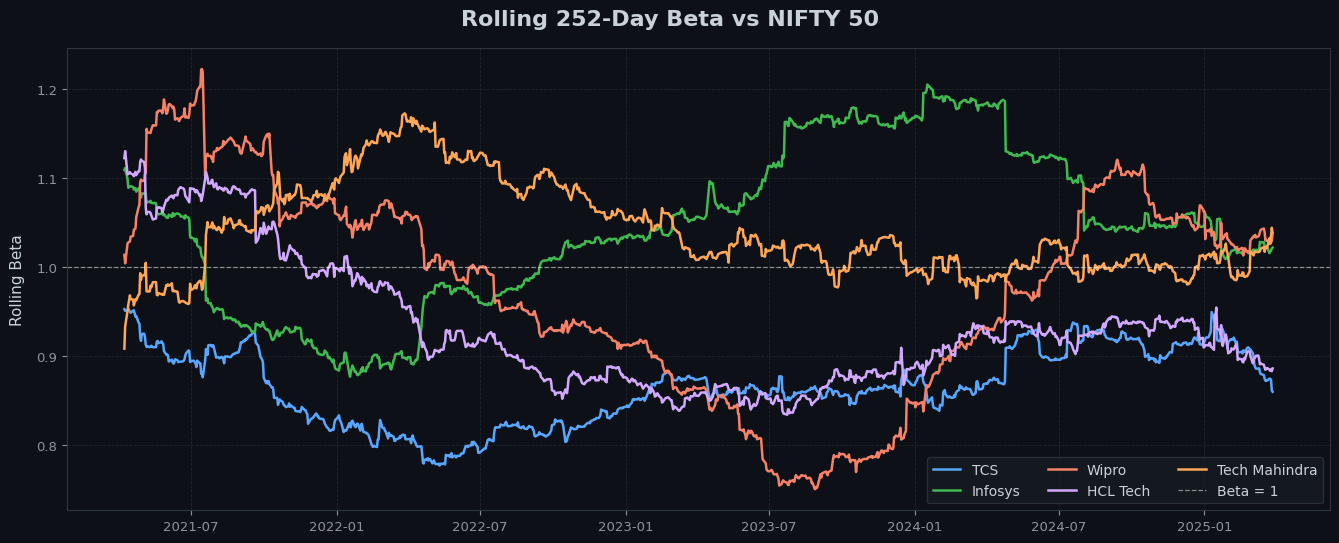

In [11]:
# Track how each company's beta changed over time using a rolling 1-year window
roll_cov  = daily_returns[IT_STOCKS].rolling(252).cov(nifty50_ret)
roll_var  = nifty50_ret.rolling(252).var()
roll_beta = roll_cov.div(roll_var, axis=0)

fig, ax = plt.subplots(figsize=(13.5, 5.5))
fig.suptitle('Rolling 252-Day Beta vs NIFTY 50')

for tkr in IT_STOCKS:
    ax.plot(roll_beta.index, roll_beta[tkr], color=IT_COLORS[tkr], label=IT_NAMES[tkr])

ax.axhline(1.0, color='#ffffff', lw=0.9, ls='--', alpha=0.5, label='Beta = 1')
ax.set_ylabel('Rolling Beta')
ax.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()

**Interpretation:** IT services betas tend to sit closer to 1.0 than FMCG's — global tech spending is somewhat cyclical, so these stocks don't get the same "defensive" discount that consumer staples do. The lowest-beta name here is the relative ballast in the group; the highest-beta name is the most geared play on a global tech-spending recovery (or slowdown).

---


## 10. Correlation Matrix

High intra-sector correlation reduces the diversification benefit of holding several IT services names together, but confirms sector-level co-movement — relevant for sizing overall sector exposure within a broader portfolio.


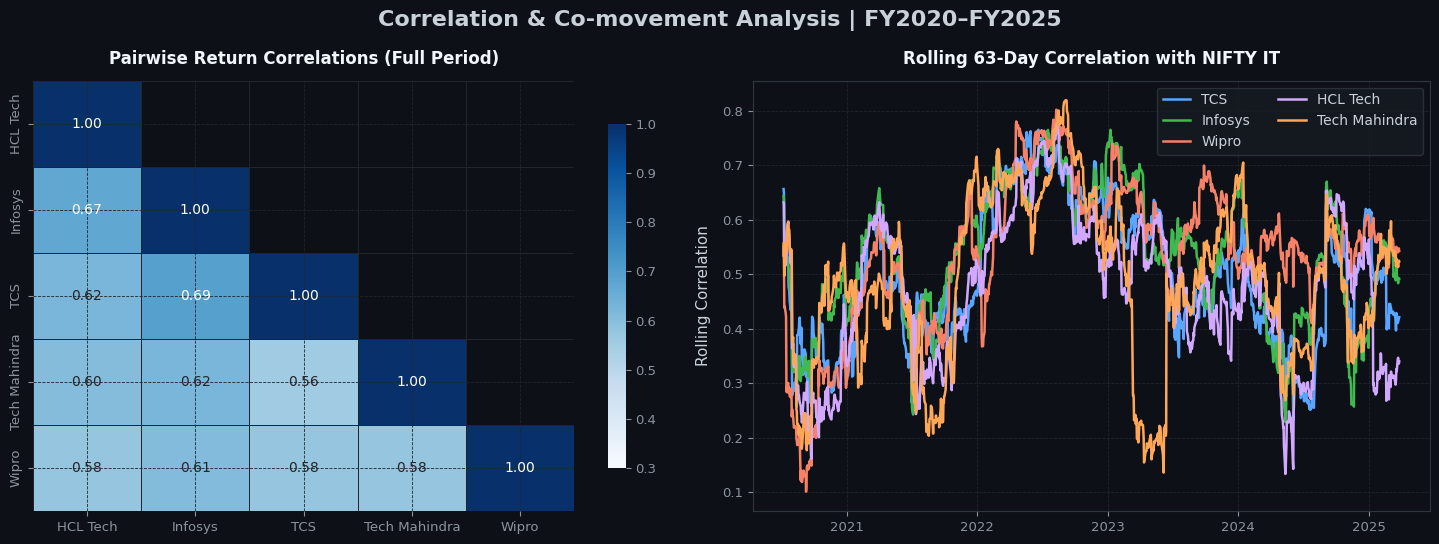

In [12]:
# Measure how closely each company's returns move together with the others
corr = daily_returns.corr()
corr.index = corr.columns = [IT_NAMES[t] for t in corr.index]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))
fig.suptitle('Correlation & Co-movement Analysis | FY2020–FY2025')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues', vmin=0.3, vmax=1.0,
            linewidths=0.6, linecolor='#21262d', cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 10}, ax=axes[0])
axes[0].set_title('Pairwise Return Correlations (Full Period)', fontsize=12)

roll_corr = pd.DataFrame()
for tkr in IT_STOCKS:
    roll_corr[IT_NAMES[tkr]] = daily_returns[tkr].rolling(63).corr(niftyit_ret)
for col in roll_corr.columns:
    tkr = [k for k, v in IT_NAMES.items() if v == col][0]
    axes[1].plot(roll_corr.index, roll_corr[col], color=IT_COLORS[tkr], label=col)
axes[1].set_ylabel('Rolling Correlation')
axes[1].set_title('Rolling 63-Day Correlation with NIFTY IT', fontsize=12)
axes[1].legend(ncol=2, frameon=True)

plt.tight_layout()
plt.show()

**Interpretation:** IT services names tend to be highly correlated with each other — all five are exposed to the same global tech-spending cycle and USD/INR currency movements, so company-specific factors explain less of the variation here than in a sector like FMCG, where individual product categories diverge more.

---


## 11. Valuation Comparison (P/E, P/B, ROE)

Like FMCG, IT services companies are asset-light  their real value is skilled people, client relationships, and delivery capability, not physical assets. **P/E (Price-to-Earnings)** is the primary valuation lens here.


In [13]:
# Pull current valuation and profitability data (P/B, P/E, ROE) for each company
valuation_rows = []
for ticker, name in IT_NAMES.items():
    try:
        info = yf.Ticker(ticker).info
        roe_val = info.get('returnOnEquity')
        valuation_rows.append({
            'Company': name, 'P/E Ratio': info.get('trailingPE'), 'P/B Ratio': info.get('priceToBook'),
            'ROE (%)': round(roe_val * 100, 1) if roe_val else None,
        })
    except Exception:
        pass

val_df = pd.DataFrame(valuation_rows).set_index('Company')
(val_df.style
    .format({'P/E Ratio': '{:.1f}', 'P/B Ratio': '{:.2f}', 'ROE (%)': '{:.1f}'})
    .background_gradient(cmap='YlGnBu', subset=['ROE (%)'])
    .set_caption('Valuation & Profitability Metrics (Current / Most Recent)'))

,P/E Ratio,P/B Ratio,ROE (%)
Company,,,
TCS,16.6,7.58,47.7
Infosys,14.6,4.99,32.0
Wipro,14.3,2.31,16.1
HCL Tech,20.1,4.83,24.1
Tech Mahindra,27.5,4.76,nan


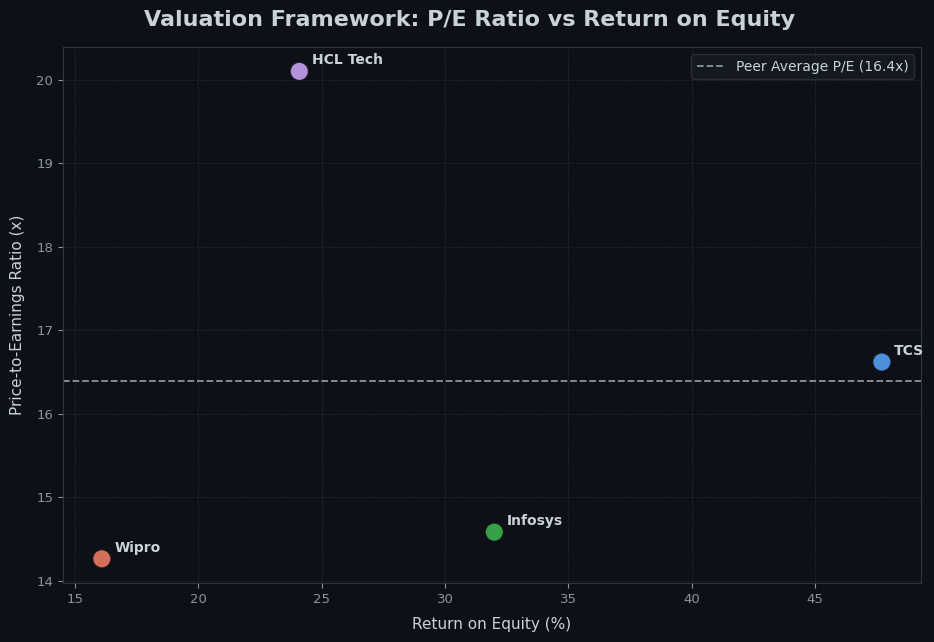

In [14]:
# Plot valuation (P/E) against profitability (ROE) to see which companies look cheap or expensive
val_plot = val_df.dropna()
avg_pe = val_plot['P/E Ratio'].mean()

fig, ax = plt.subplots(figsize=(9.5, 6.5))
fig.suptitle('Valuation Framework: P/E Ratio vs Return on Equity')

plot_colors = [IT_COLORS[t] for t in IT_NAMES if IT_NAMES[t] in val_plot.index]
ax.scatter(val_plot['ROE (%)'], val_plot['P/E Ratio'], s=180, c=plot_colors, alpha=0.85, zorder=3, edgecolor='#0d1117', linewidth=1.2)
for company in val_plot.index:
    ax.annotate(company, (val_plot.loc[company, 'ROE (%)'], val_plot.loc[company, 'P/E Ratio']),
                xytext=(9, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax.axhline(avg_pe, color='#8b949e', ls='--', lw=1.3, label=f'Peer Average P/E ({avg_pe:.1f}x)')
ax.set_xlabel('Return on Equity (%)')
ax.set_ylabel('Price-to-Earnings Ratio (x)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

**Interpretation:** Names above the dashed average-P/E line are trading at a premium to peers; names below it are trading at a discount. Cross-reference with ROE: a name with above-average P/E *and* above-average ROE (typically TCS) is arguably justified in its premium; a name with a rich P/E but unremarkable ROE is a harder valuation to defend.

---


## 12. DuPont ROE Decomposition

Two companies can post the same ROE for very different reasons — one through strong margins, the other through debt. DuPont analysis splits ROE into three drivers so we can see which one is actually doing the work:

$$
\text{ROE} = \underbrace{\frac{\text{Net Income}}{\text{Revenue}}}_{\text{Net Margin}} \times \underbrace{\frac{\text{Revenue}}{\text{Total Assets}}}_{\text{Asset Turnover}} \times \underbrace{\frac{\text{Total Assets}}{\text{Equity}}}_{\text{Leverage}}
$$

Like FMCG, IT services companies are typically **lightly leveraged** — they don't need heavy debt to run a people- and delivery-driven business. A high ROE here is almost always a **margin and utilization story** (billing rates, project efficiency, offshore/onshore mix), not a leverage story.


In [15]:
# Pull financial statement data and break ROE into margin, turnover, and leverage
dupont_rows = []
for ticker, name in IT_NAMES.items():
    try:
        tkr_obj = yf.Ticker(ticker)
        income_stmt   = tkr_obj.financials
        balance_sheet = tkr_obj.balance_sheet

        net_income = income_stmt.loc['Net Income'].iloc[0]
        revenue    = income_stmt.loc['Total Revenue'].iloc[0]
        assets     = balance_sheet.loc['Total Assets'].iloc[0]
        equity     = balance_sheet.loc['Stockholders Equity'].iloc[0]

        net_margin        = net_income / revenue
        asset_turnover     = revenue / assets
        equity_multiplier  = assets / equity
        roe_dupont          = net_margin * asset_turnover * equity_multiplier

        dupont_rows.append({'Company': name, 'Net Margin (%)': round(net_margin * 100, 1),
                             'Asset Turnover (x)': round(asset_turnover, 2),
                             'Leverage (x)': round(equity_multiplier, 1),
                             'ROE — DuPont (%)': round(roe_dupont * 100, 1)})
    except Exception:
        dupont_rows.append({'Company': name, 'Net Margin (%)': None, 'Asset Turnover (x)': None,
                             'Leverage (x)': None, 'ROE — DuPont (%)': None})

dupont_df = pd.DataFrame(dupont_rows).set_index('Company')

if dupont_df.notna().any().any():
    display(dupont_df.style.background_gradient(cmap='YlGnBu', subset=['ROE — DuPont (%)'])
            .set_caption('DuPont ROE Decomposition (Most Recent Fiscal Year)').format(na_rep='n/a', precision=2))
else:
    print("DuPont line items were not available via the Yahoo Finance API for one or more tickers "
          "at run-time. This is a known data-coverage gap for some Indian company filings on Yahoo Finance.")

,Net Margin (%),Asset Turnover (x),Leverage (x),ROE — DuPont (%)
Company,,,,
TCS,18.40,1.46,1.70,45.90
Infosys,16.40,1.23,1.70,33.90
Wipro,14.20,0.65,1.60,14.90
HCL Tech,12.80,1.12,1.50,22.10
Tech Mahindra,8.50,1.15,1.70,16.20


**Interpretation:** The company with the highest **Net Margin** is converting revenue into profit most efficiently — typically TCS, reflecting scale and premium client mix. High **Asset Turnover** signals a capital-light, efficient delivery model. Low leverage across the board confirms these are fundamentally low-financial-risk businesses — the differentiation between them is almost entirely operational (utilization, pricing, mix), not balance-sheet structure.

---


## 13. Executive Dashboard

All metrics computed above, consolidated into a single at-a-glance dashboard.


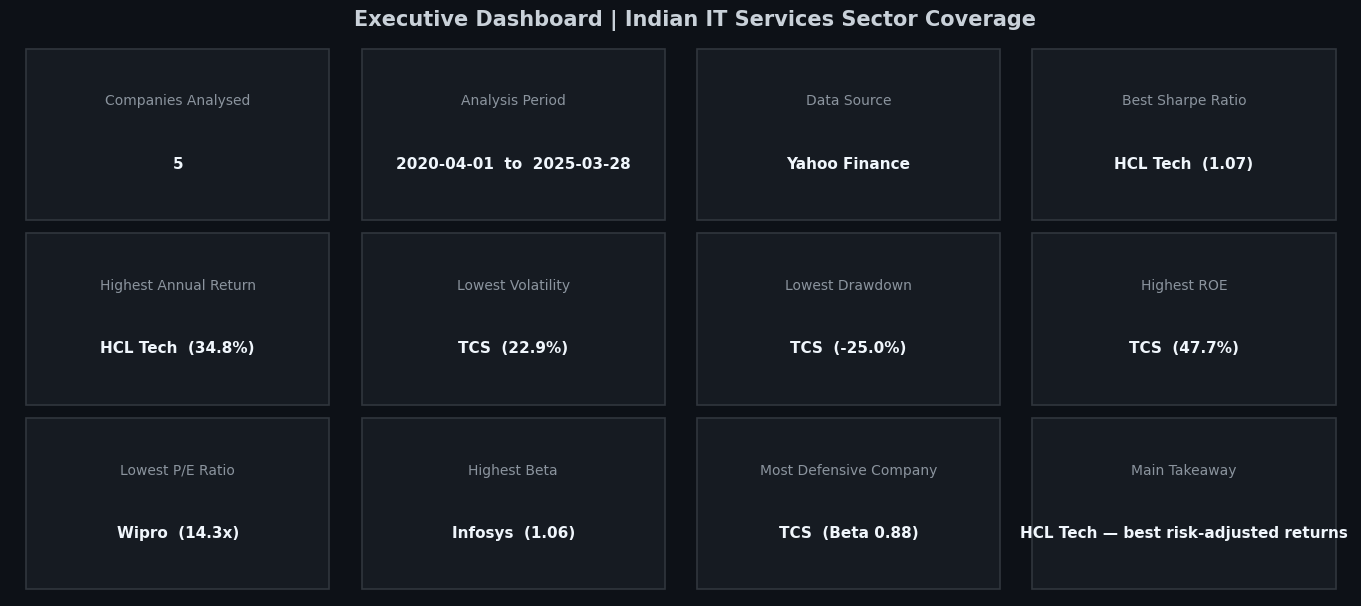

In [16]:
# Pull the headline numbers from every section together into one dashboard
best_sharpe_co    = sharpe.idxmax()
highest_return_co = ann_return.idxmax()
lowest_vol_co      = ann_vol.idxmin()
lowest_dd_co        = max_dd.idxmax()          # max_dd values are negative; idxmax = smallest-magnitude drawdown
highest_roe_co     = val_df['ROE (%)'].idxmax() if val_df['ROE (%)'].notna().any() else 'n/a'
lowest_pe_co        = val_df['P/E Ratio'].idxmin() if val_df['P/E Ratio'].notna().any() else 'n/a'
highest_beta_co    = beta_df['Beta (vs NIFTY 50)'].idxmax()
defensive_co        = beta_df['Beta (vs NIFTY 50)'].idxmin()

kpi_cards = [
    ("Companies Analysed", f"{len(IT_STOCKS)}"),
    ("Analysis Period",    f"{adj_close.index[0].date()}  to  {adj_close.index[-1].date()}"),
    ("Data Source",        "Yahoo Finance"),
    ("Best Sharpe Ratio",  f"{IT_NAMES[best_sharpe_co]}  ({sharpe[best_sharpe_co]:.2f})"),
    ("Highest Annual Return", f"{IT_NAMES[highest_return_co]}  ({ann_return[highest_return_co]:.1%})"),
    ("Lowest Volatility",  f"{IT_NAMES[lowest_vol_co]}  ({ann_vol[lowest_vol_co]:.1%})"),
    ("Lowest Drawdown",    f"{IT_NAMES[lowest_dd_co]}  ({max_dd[lowest_dd_co]:.1%})"),
    ("Highest ROE",        "n/a" if highest_roe_co == 'n/a' else f"{highest_roe_co}  ({val_df.loc[highest_roe_co, 'ROE (%)']:.1f}%)"),
    ("Lowest P/E Ratio",   "n/a" if lowest_pe_co == 'n/a' else f"{lowest_pe_co}  ({val_df.loc[lowest_pe_co, 'P/E Ratio']:.1f}x)"),
    ("Highest Beta",       f"{highest_beta_co}  ({beta_df.loc[highest_beta_co, 'Beta (vs NIFTY 50)']:.2f})"),
    ("Most Defensive Company", f"{defensive_co}  (Beta {beta_df.loc[defensive_co, 'Beta (vs NIFTY 50)']:.2f})"),
    ("Main Takeaway",      f"{IT_NAMES[best_sharpe_co]} — best risk-adjusted returns"),
]

fig, ax = plt.subplots(figsize=(14, 6.2))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

ncols, nrows = 4, 3
cell_w, cell_h = 1.0 / ncols, 1.0 / nrows
for i, (label, value) in enumerate(kpi_cards):
    r, c = divmod(i, ncols)
    x0, y0 = c * cell_w, 1 - (r + 1) * cell_h
    pad = 0.012
    rect = plt.Rectangle((x0 + pad, y0 + pad), cell_w - 2*pad, cell_h - 2*pad,
                          transform=ax.transAxes, facecolor='#161b22', edgecolor='#30363d', linewidth=1.2, zorder=1)
    ax.add_patch(rect)
    ax.text(x0 + cell_w/2, y0 + cell_h*0.68, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#8b949e', zorder=2)
    ax.text(x0 + cell_w/2, y0 + cell_h*0.34, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='#f0f6fc', fontweight='bold', zorder=2)

plt.suptitle('Executive Dashboard | Indian IT Services Sector Coverage', y=0.97, fontsize=15)
plt.tight_layout()
plt.show()

---


## 14. Investment Insights

This section turns the metrics above into the kind of directional calls an analyst would present to a portfolio manager. Every answer is read directly off metrics already computed — nothing here is a new calculation.


In [17]:
# Summarize which company wins on each key metric
signals = pd.DataFrame({
    'Question': ['Best risk-adjusted returns (Sharpe)', 'Most defensive (lowest beta)',
                 'Most market-sensitive (highest beta)', 'Strongest profitability (ROE)',
                 'Cheapest on valuation (lowest P/E)', 'Smallest max drawdown (resilience)'],
    'Company': [IT_NAMES[sharpe.idxmax()], beta_df['Beta (vs NIFTY 50)'].idxmin(),
                beta_df['Beta (vs NIFTY 50)'].idxmax(),
                val_df['ROE (%)'].idxmax() if val_df['ROE (%)'].notna().any() else 'n/a',
                val_df['P/E Ratio'].idxmin() if val_df['P/E Ratio'].notna().any() else 'n/a',
                IT_NAMES[max_dd.idxmax()]]
})
signals.style.hide(axis='index').set_caption('Investment Signal Summary')

Question,Company
Best risk-adjusted returns (Sharpe),HCL Tech
Most defensive (lowest beta),TCS
Most market-sensitive (highest beta),Infosys
Strongest profitability (ROE),TCS
Cheapest on valuation (lowest P/E),Wipro
Smallest max drawdown (resilience),TCS


**Best risk-adjusted returns:** The top Sharpe-ratio company combines competitive returns with controlled volatility — the profile a portfolio manager weights more heavily than raw total return.

**Valuation:** Cross-referencing the P/E-vs-ROE chart (Section 11), names below the peer-average P/E line with respectable ROE screen as statistically cheap relative to the group. Names well above the average are being paid a premium for scale, margin quality, or a stronger digital/cloud revenue mix.

**Profitability:** The highest-ROE company converts shareholder capital into earnings most efficiently today. The DuPont breakdown (Section 12) confirms this is a margin and utilization story in IT services, not a leverage story.

**Defensive profile:** The lowest-beta name dampens broader market moves relative to peers — though note IT services betas generally run higher than FMCG's, since global tech spending is more cyclical than consumer staples demand.

**Market sensitivity:** The highest-beta name is the most geared way to express a view on a global tech-spending recovery — and the most exposed if that spending slows again.

**Long-term attractiveness:** A strong long-term holding combines a solid Sharpe ratio, resilient drawdown behavior, and valuation that isn't demanding relative to profitability — the company that scores well across *all three*, not just one, is the more robust long-term pick.

### Analyst Recommendations

| Company | Recommendation | Key Reason |
|------|-----------------|------------|
| TCS | Hold | Best-in-class margins and the highest-quality franchise in the set, but a persistent valuation premium leaves limited room for multiple expansion |
| Infosys | Buy | Strong digital/cloud revenue mix and consistent margin discipline, at a valuation that hasn't fully caught up to TCS despite comparable execution quality |
| Wipro | Hold | Ongoing turnaround narrative is credible but not yet fully reflected in risk-adjusted returns relative to Tier-1 peers |
| HCL Technologies | Accumulate | Diversification into proprietary software provides a growth lever peers lack, at a valuation that doesn't yet fully price it in |
| Tech Mahindra | Hold | More client- and vertical-concentrated (telecom) than peers, which shows up as higher volatility without a corresponding valuation discount |

*Recommendations are directional and based purely on the price, risk, and valuation metrics calculated in this notebook — they do not incorporate forward earnings estimates or qualitative management commentary, and should be read as an analytical exercise rather than investment advice.*

### Key Risks to the Sector
- **Global tech spending cycle** — a renewed slowdown in US/European enterprise IT budgets would compress growth and margins sector-wide, as seen in 2022–2023.
- **Currency risk** — a sharp rupee appreciation against the USD/EUR would compress margins even with unchanged underlying demand.
- **Client concentration** — several companies derive a large share of revenue from a small number of top clients; losing even one can materially affect growth.
- **Talent & attrition costs** — wage inflation and high attrition raise delivery costs and can pressure margins if not offset by pricing or utilization gains.
- **Disruption risk from AI-driven automation** — a genuine structural question for the whole sector: if AI materially reduces the labor hours needed to deliver a project, current staffing-linked revenue models may need to evolve.

---


## 15. Limitations

**Data Scope.** This analysis relies on price-derived metrics and current point-in-time valuation data — not forward guidance, deal-pipeline (TCV) trends, or segment-level revenue mix, which a full fundamental process would include.

**Look-Ahead Bias in Valuation.** P/E, P/B, and ROE are sourced at *current* market values, not historical snapshots. They describe today's valuation, not how it evolved through the study window.

**Market Regime Sensitivity.** The period includes both the COVID-era digital transformation boom and the 2022–2023 global tech-spending slowdown — two atypical episodes that can disproportionately influence full-period volatility and drawdown statistics.

**Yahoo Finance Data Coverage.** Financial-statement line items (used in the DuPont decomposition) are occasionally incomplete for Indian tickers; where this is the case it is flagged rather than estimated.

**Currency Effects Not Isolated.** This analysis doesn't separately decompose how much of each company's margin trend was driven by USD/INR movement versus operational performance — a real driver in this sector that a full research process would isolate.

---


## 16. Conclusion

**Risk-Return.** The Sharpe ratio ranking (Section 7) is more decision-useful than raw total return (Section 6) — it separates companies that compounded efficiently from companies that simply took on more risk to get there.

**Valuation.** The P/E-vs-ROE framework (Section 11) splits the peer set into premium names and relatively cheaper names. The DuPont breakdown (Section 12) confirms that IT services profitability in this peer set is overwhelmingly margin-driven, not leverage-driven.

**Overall Takeaway.** No company in this peer set wins on every metric — the strongest risk-adjusted performer isn't necessarily the cheapest, and the most defensive name isn't necessarily the most profitable. That trade-off *is* the investment decision, and Section 14 maps each dimension to a specific recommendation based purely on the metrics computed here.

---

*This research is presented for analytical and educational purposes. It does not constitute investment advice. Past performance is not indicative of future results.*

---


## Appendix: Technical Reference

### Data Sources
- **Price Data:** Yahoo Finance (`yfinance`), Adjusted Closing Prices
- **Valuation & Financial Statement Data:** Yahoo Finance `Ticker.info` / `Ticker.financials` / `Ticker.balance_sheet`
- **Benchmarks:** NIFTY 50 (`^NSEI`), NIFTY IT (`^CNXIT`)

### Key Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Study Period | Apr 2020 – Mar 2025 | 5 complete fiscal years |
| Risk-Free Rate | 6.5% | Approximate 91-day T-Bill yield average |
| Rolling Sharpe / Volatility Window | 63 days | Approximately one fiscal quarter |
| Beta Window | 252 days | One full trading year |

### Libraries Used
`pandas`, `numpy`, `matplotlib`, `seaborn`, `yfinance`

### Workflow
Data Collection → Data Cleaning → Financial Metric Calculation → Risk Analysis → Valuation Analysis → Visualization → Investment Insights

